In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
import sys
import os
sys.path.append('/rhome/sawale/indus_traning/mlm-fine-tuning/mlm')

In [3]:
import pandas as pd

In [4]:
data = pd.read_parquet("../data/parsed_sde_init_check_with_title.parquet")

# remove empty text fields
data = data[data['text'] != ""]

# drop duplicates
data = data.drop_duplicates(subset=['text'])

data["text"] = data.apply(lambda x: x["text"].strip(), axis=1)
data["line"] = data.apply(lambda x: x["text"].split("\n"), axis=1)

data["word_counts"] = data.apply(lambda x: [len([w for w in l.split(" ") if w != ""]) for l in x["line"]], axis=1)

data.shape

(97443, 15)

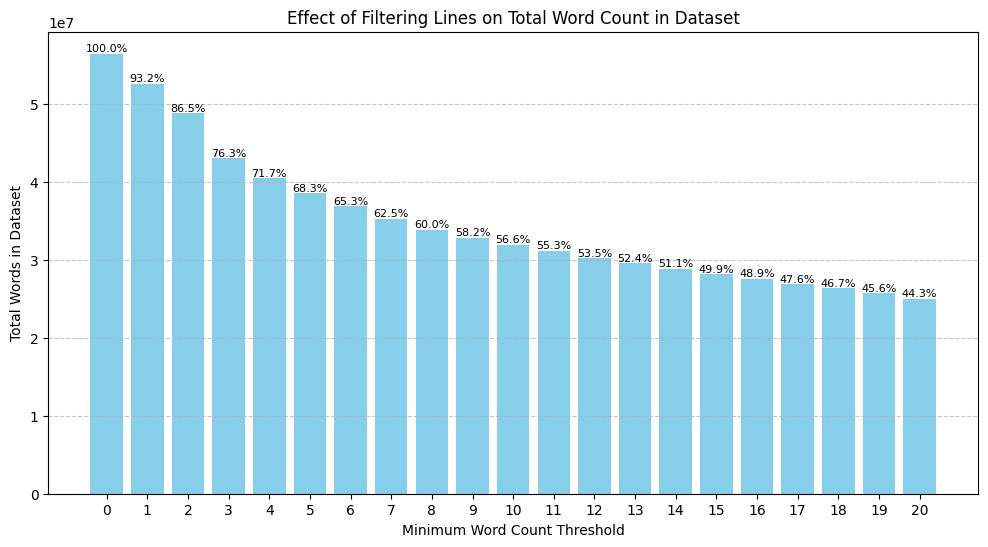

In [28]:

import pandas as pd
import matplotlib.pyplot as plt

exploded_data = data.explode("line")
exploded_data["n_words"] = exploded_data["line"].apply(lambda x: len([i for i in x.split(" ") if i != ""]))


# Assuming `exploded_data` is already defined
word_counts = []
total_words = exploded_data["n_words"].sum()  # Total words before any filtering
percentages = []

for threshold in range(21):
    filtered_data = exploded_data[exploded_data["n_words"] > threshold]
    filtered_word_count = filtered_data["n_words"].sum()
    word_counts.append(filtered_word_count)
    percentages.append((filtered_word_count / total_words) * 100)  # Compute percentage

# Plot the results as a bar chart
plt.figure(figsize=(12, 6))
bars = plt.bar(range(21), word_counts, color='skyblue')

plt.xlabel("Minimum Word Count Threshold")
plt.ylabel("Total Words in Dataset")
plt.title("Effect of Filtering Lines on Total Word Count in Dataset")
plt.xticks(range(21))
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Annotate each bar with the percentage of words remaining
for bar, percent in zip(bars, percentages):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f"{percent:.1f}%", 
             ha='center', va='bottom', fontsize=8)

plt.show()



# Genrating new filtered data

In [7]:
def gen_new_text(row, threshold=2):
    new_text = ""
    lines = row["line"]
    word_counts = row["word_counts"]

    for l, wc in zip(lines, word_counts):
        if wc > threshold:
            new_text += l + "\n"
    return new_text

data["new_text"] = data.apply(lambda x: gen_new_text(x, threshold=2), axis=1)
# update rename text columns
data = data.rename(columns={"text": "old_text", "new_text": "text"})

In [10]:
data[["old_text", "text"]].iloc[0]

old_text    TOOLKIT\n\nCONTESTS\n\nWEBINARS\n\nGET INVOLVE...
text        Earth Science Week\nCelebrate "Earth Science E...
Name: 0, dtype: object

In [11]:
data.to_parquet("../data/parsed_sde_init_check_with_title_filtered_word_count.parquet", index=False)

In [1]:
import pandas as pd

data = pd.read_parquet("../data/parsed_sde_init_check_with_title_filtered_word_count.parquet")

In [3]:
# remove empty text fields
data = data[data['text'] != ""]

# drop duplicates
data = data.drop_duplicates(subset=['text'])

data.shape


(97023, 16)

In [8]:
# check how many lines were removed due to this filtering
# Count the number of new lines in each column
data["old_text_newlines"] = data["old_text"].str.count("\n")
data["text_newlines"] = data["text"].str.count("\n")

# Sum total new lines in each column
total_old_text_newlines = data["old_text_newlines"].sum()
total_text_newlines = data["text_newlines"].sum()

print("Total new lines in old_text:", total_old_text_newlines)
print("Total new lines in text:", total_text_newlines)

print(f"New data has {round(total_text_newlines/total_old_text_newlines, 6)*100}% of the lines in the original data.")

Total new lines in old_text: 20642745
Total new lines in text: 4730884
New data has 22.9179% of the lines in the original data.
